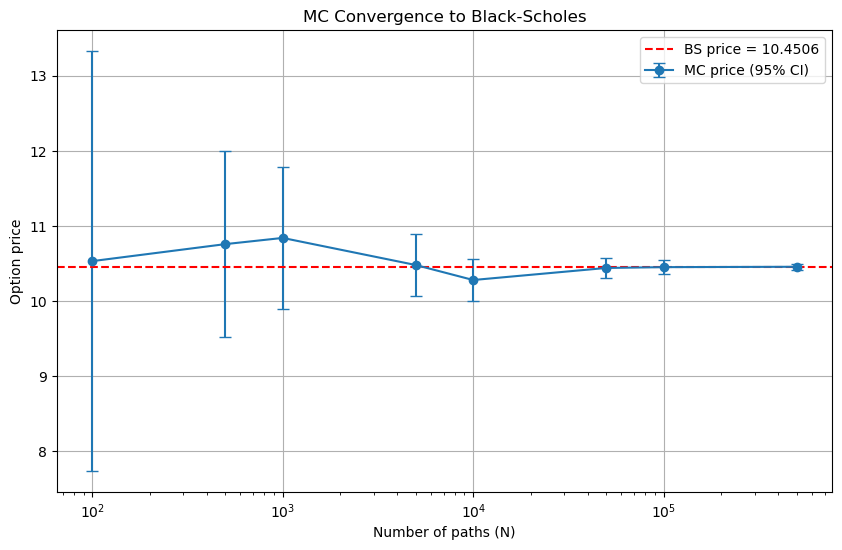

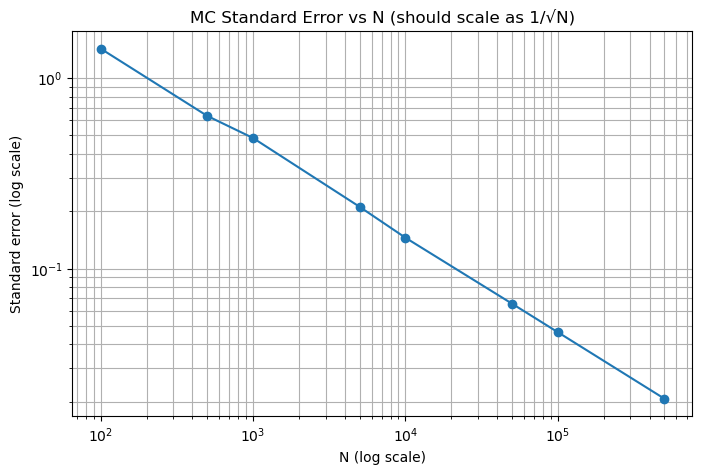

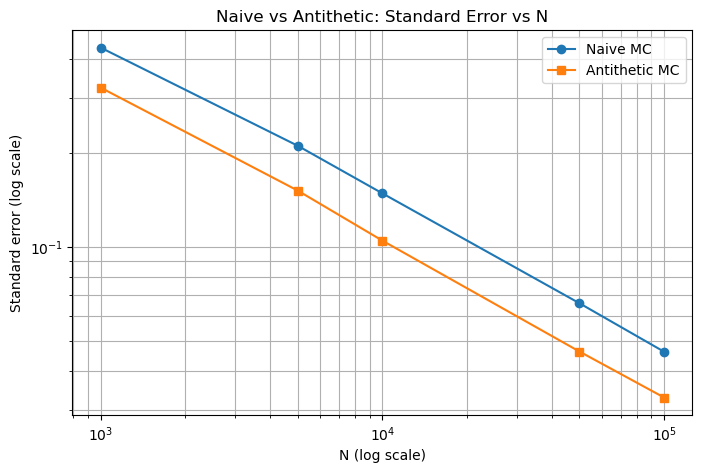

Naive SE: 0.14787
Antithetic SE: 0.10113
Variance reduction ratio: 2.14x


In [1]:
from scipy.stats import norm
import numpy as np
import time
import import_ipynb
from Geometric_Brownian_Motion import simulate_GBM, simulate_GBM_antithetic
from Black_Scholes_Closed_Form import european_mc, european_mc_antithetic
import matplotlib.pyplot as plt
from scipy.stats import qmc

In [2]:
def european_mc_control_variate(S0, K, r, sigma, T, n, n_paths, type="call"):
    t, S = simulate_GBM(S0, r, sigma, T, n, n_paths)
    S_T = S[:, -1]
    
    if type == "call":
        payoff = np.maximum(S_T - K, 0)
    else:
        payoff = np.maximum(K - S_T, 0)
    
    discounted_payoff = np.exp(-r*T) * payoff
    
    # control variate: S_T, with known expectation
    E_S_T = S0 * np.exp(r*T)
    
    # optimal beta from sample covariance
    cov_matrix = np.cov(discounted_payoff, S_T)
    beta = cov_matrix[0, 1] / cov_matrix[1, 1]
    
    controlled = discounted_payoff - beta * (S_T - E_S_T)
    
    price = controlled.mean()
    std_err = controlled.std(ddof=1) / np.sqrt(n_paths)
    return price, std_err

In [3]:
def simulate_GBM_sobol(S0, mu, sigma, T, n, n_paths):
    dt = T / n
    t = np.linspace(0, T, n + 1)
    
    sampler = qmc.Sobol(d=n, scramble=True)

    m = int(np.ceil(np.log2(n_paths)))
    U = sampler.random_base2(m=m)[:n_paths]  
    
    Z = norm.ppf(U)  
    Z = np.clip(Z, -8, 8) 
    
    W = np.cumsum(np.sqrt(dt) * Z, axis=1)
    W = np.hstack((np.zeros((n_paths, 1)), W))
    
    drift = (mu - 0.5 * sigma**2) * t
    shock = sigma * W
    S = S0 * np.exp(drift + shock)
    return t, S

In [4]:
def european_sobol_terminal(S0, K, r, sigma, T, n_paths, type="call"):
    sampler = qmc.Sobol(d=1, scramble=True)
    m = int(np.ceil(np.log2(n_paths)))
    U = sampler.random_base2(m=m)[:n_paths, 0]
    Z = norm.ppf(U)
    Z = np.clip(Z, -8, 8)
    
    S_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    
    if type == "call":
        payoff = np.maximum(S_T - K, 0)
    else:
        payoff = np.maximum(K - S_T, 0)
    
    discounted = np.exp(-r*T) * payoff
    price = discounted.mean()
    std_err = discounted.std(ddof=1) / np.sqrt(n_paths)
    return price, std_err

In [7]:
def european_sobol_rqmc_error(S0, K, r, sigma, T, n_paths, n_repeats=20, type="call"):
    prices = []
    for _ in range(n_repeats):
        sampler = qmc.Sobol(d=1, scramble=True)  # new random scramble each call
        m = int(np.ceil(np.log2(n_paths)))
        U = sampler.random_base2(m=m)[:n_paths, 0]
        Z = np.clip(norm.ppf(U), -8, 8)
        
        S_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
        if type == "call":
            payoff = np.maximum(S_T - K, 0)
        else:
            payoff = np.maximum(K - S_T, 0)
        
        price = (np.exp(-r*T) * payoff).mean()
        prices.append(price)
    
    prices = np.array(prices)
    mean_price = prices.mean()
    std_err = prices.std(ddof=1) / np.sqrt(n_repeats)  # error across independent scrambled runs
    return mean_price, std_err

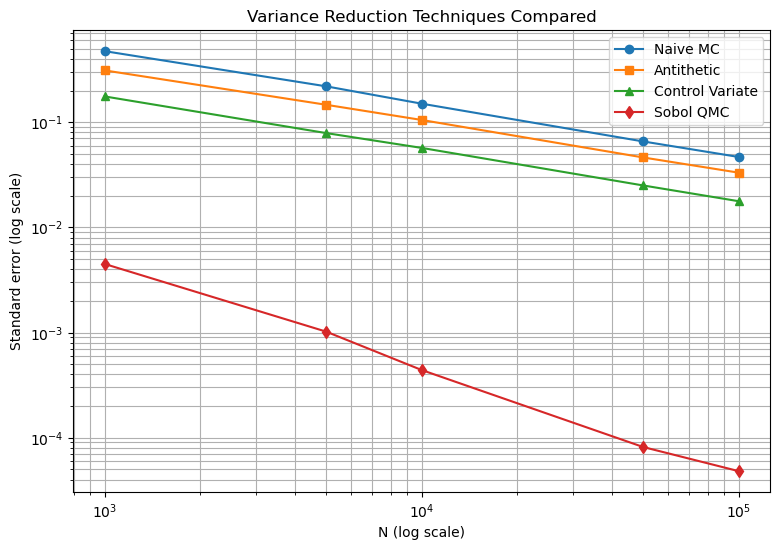

In [8]:
N_values = [1000, 5000, 10000, 50000, 100000]
S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1.0
naive_errors, antithetic_errors, cv_errors, sobol_errors = [], [], [], []

for N in N_values:
    _, se_naive = european_mc(S0, K, r, sigma, T, n=252, n_paths=N, type="call")
    _, se_anti  = european_mc_antithetic(S0, K, r, sigma, T, n=252, n_paths=N, type="call")
    _, se_cv    = european_mc_control_variate(S0, K, r, sigma, T, n=252, n_paths=N, type="call")
    _, se_sobol = european_sobol_rqmc_error(S0, K, r, sigma, T, n_paths=N, type="call")
    
    naive_errors.append(se_naive)
    antithetic_errors.append(se_anti)
    cv_errors.append(se_cv)
    sobol_errors.append(se_sobol)

plt.figure(figsize=(9,6))
plt.loglog(N_values, naive_errors, 'o-', label="Naive MC")
plt.loglog(N_values, antithetic_errors, 's-', label="Antithetic")
plt.loglog(N_values, cv_errors, '^-', label="Control Variate")
plt.loglog(N_values, sobol_errors, 'd-', label="Sobol QMC")
plt.xlabel("N (log scale)")
plt.ylabel("Standard error (log scale)")
plt.title("Variance Reduction Techniques Compared")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [9]:
price, se = european_sobol_rqmc_error(S0, K, r, sigma, T, n_paths=10000, type="call")
print(f"Sobol RQMC price: {price:.4f}, BS price: 10.4506")

Sobol RQMC price: 10.4506, BS price: 10.4506


In [10]:
print(f"Naive:     {naive_errors[-1]:.5f}")
print(f"Antithetic: {antithetic_errors[-1]:.5f}")
print(f"Control variate: {cv_errors[-1]:.5f}")
print(f"Sobol RQMC: {sobol_errors[-1]:.5f}")
print(f"Sobol speedup over naive: {naive_errors[-1]/sobol_errors[-1]:.1f}x")

Naive:     0.04669
Antithetic: 0.03311
Control variate: 0.01773
Sobol RQMC: 0.00005
Sobol speedup over naive: 971.3x
